In [5]:
# Adapted from https://github.com/elstonlab/PhagocytosisRosetteModel/blob/main/WPGAP_FP_Check_EA_Results.ipynb by J. Cody Herron
import numpy as np
from scipy.integrate import odeint
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os

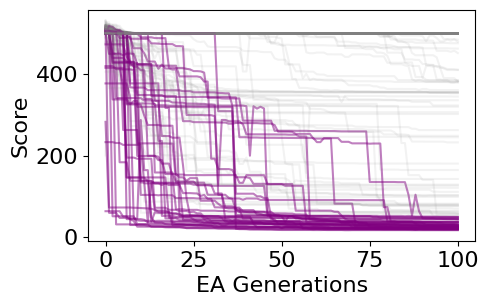

In [6]:
folder = os.getcwd()
file_loc = folder

threshold_good_score = 50 # Threshold for fitness function to be considered as a successful round of parameter searching
path, dirs, files = os.walk(file_loc).__next__()
len_files = 501 # Total number of rounds of parameter searching

runs_df = pd.DataFrame(index = range(len_files), columns=['Score','a_act', 'd_act', 'K_n', 'n', 'a_x', 'd_x', 'm',
                                                          'K_S', 'K_a', 'k1', 'k2', 'k4', 'k3', 'XbsT', 'sT']) # Load optimized parameters
best_scores = []
best_inds = []
plt.figure(figsize=(5,3))
for i in range(len_files):
    logbook = pickle.load( open( folder + '/' + str(i) + ".pickled", "rb" ) )
    runs_df.iloc[i] = np.insert(logbook[1][-1],0,logbook[0][-1])
        
    best_scores.append(logbook[0][-1])
    best_inds.append(logbook[1][-1])
  
    run = np.array(logbook[0])
    score = logbook[0][-1]
    if score < threshold_good_score:
        plt.plot(run,color='purple',alpha=.5)  
    else:
        plt.plot(run,color='gray',alpha=0.1)

plt.xlabel('EA Generations')
plt.ylabel('Score')
plt.rcParams.update({'font.size': 16})

best_scores = np.array(best_scores)
plt.savefig(folder+'/Scores.png',bbox_inches='tight',dpi=300)

In [7]:
good_df = runs_df[runs_df['Score'] < threshold_good_score].sort_values('Score')
good_df.to_csv('Parameters_for_activator_inhibition.csv', index=False)

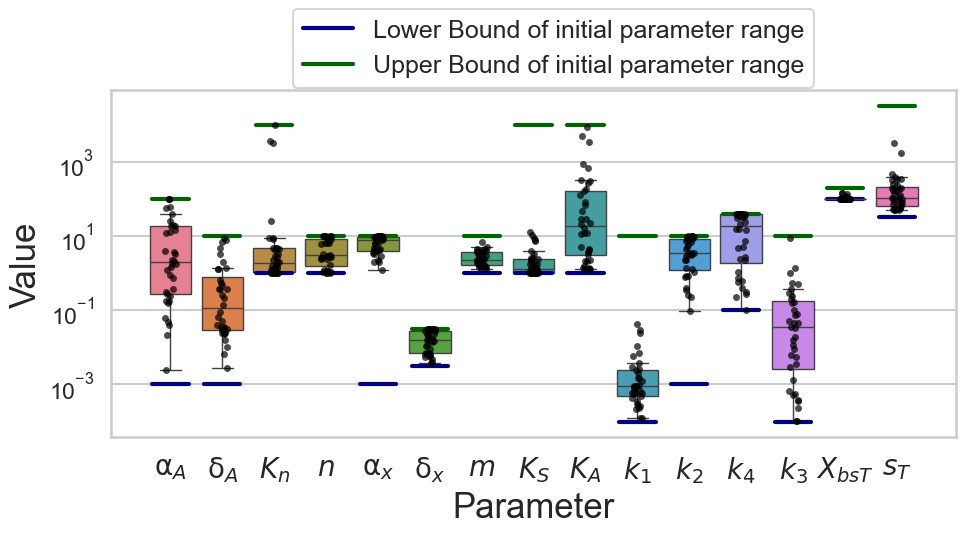

In [8]:
# Upper and lower bounds of model parameters 
a_act_min = -3 # activator synthesis rate from single X chromosome
a_act_max =  2

d_act_min = -3 # degradation rate of free activator
d_act_max = 1

K_n_min = 0 # quantity of bound SPEN at which activator synthesis rate is half max.
K_n_max = 4

n_min = 0 # Hill coefficient for SPEN supressing activator synthesis rate
n_max = 1

a_x_min = -3 # xist synthesis rate from single X chromosome
a_x_max = 1

d_x_min = -2.5 # degradation rate of Xist
d_x_max = -1.5

m_min = 0  # Hill coefficient for bound SPEN reducing dissociation rate Xist
m_max = 1

K_S_min = 0 # quantity of SPEN at which Xist dissociation is half max
K_S_max = 4

K_a_min = 0 # quantity of activator at which Xist transcription is half max
K_a_max = 4

k1_min = -4 # rate constant for Xist binding to DNA
k1_max = 1

k2_min = -3 # dissociation rate for Xist
k2_max = 1

k4_min = -1 # dissoication rate for bound SPEN
k4_max = 1.6

k3_min = -4 # association rate for SPEN
k3_max = 1

sT_min = 1.5 # total SPEN quantity
sT_max = 4.5

XbsT_min = 2 # total Xist binding sites on one single chromosome
XbsT_max = 2.3

# Set a clean style and context for the plot
sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(10,6))
curr_df = good_df.drop(columns=['Score'])

# Use a pastel color palette for the boxplot
num_boxes = curr_df.shape[1]
unique_colors = sns.color_palette("husl", num_boxes)
sns.boxplot(data=curr_df, showfliers=False, palette=unique_colors)

# Use a softer gray for the stripplot
sns.stripplot(data=curr_df, color='k', alpha=0.7)

plt.ylabel('Value', fontsize=25)
plt.xlabel('Parameter',fontsize=25)
plt.yscale('log')

# Calculate boundaries (example provided with np.power)
lower_bounds = np.power(10, [a_act_min, d_act_min, K_n_min, n_min, a_x_min, d_x_min, 
                               m_min, K_S_min, K_a_min, k1_min, k2_min, k4_min, 
                               k3_min, XbsT_min, sT_min])
upper_bounds = np.power(10, [a_act_max, d_act_max, K_n_max, n_max, a_x_max, d_x_max, 
                               m_max, K_S_max, K_a_max, k1_max, k2_max, k4_max, 
                               k3_max, XbsT_max, sT_max])

# Plot the boundaries with a more subtle style
for i, (low, high) in enumerate(zip(lower_bounds, upper_bounds)):
    plt.plot([i-0.35, i+0.35], [low, low], color='navy', linestyle='-', linewidth=3,
             label='Lower Bound of initial parameter range' if i == 0 else "")
    plt.plot([i-0.35, i+0.35], [high, high], color='darkgreen', linestyle='-', linewidth=3,
             label='Upper Bound of initial parameter range' if i == 0 else "")
plt.xticks(range(0,15),[r'$\mathrm{\alpha}_{A}$',r'$\mathrm{\delta}_{A}$','$K_n$','$n$',r'$\mathrm{\alpha}_x$',r'$\mathrm{\delta}_x$','$m$','$K_S$','$K_A$',
           '$k_1$','$k_2$','$k_4$','$k_3$','$X_{bsT}$','$s_T$'],fontsize=20)

plt.legend(loc='upper left', bbox_to_anchor=(0.2, 1.27), fontsize=18)
plt.tight_layout()

plt.savefig(folder+'/EAParams.png', bbox_inches='tight', dpi=300)
plt.savefig(folder+'/EAParams.pdf', bbox_inches='tight', dpi=300)
plt.show()


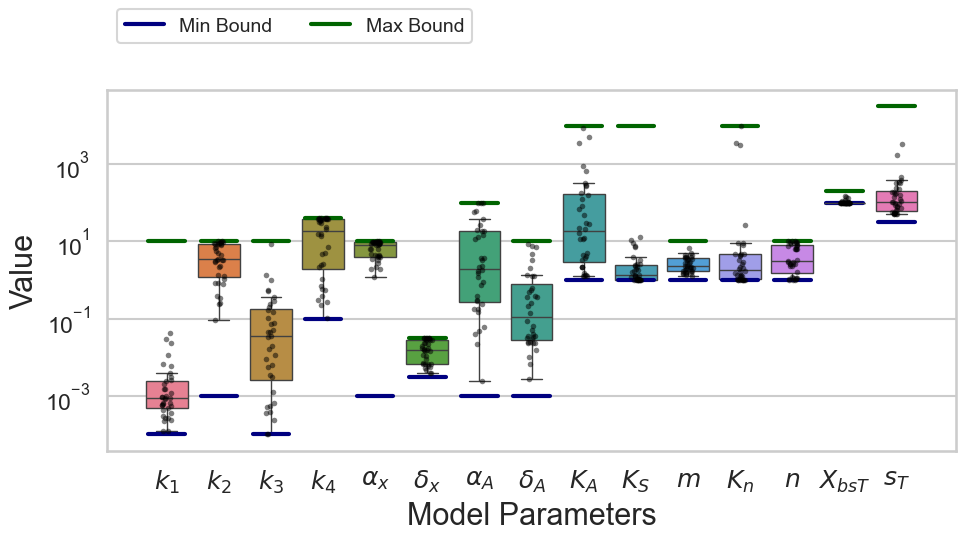

In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Map your desired order to the DataFrame column names and their bounds
# Format: 'DataFrame_Column': (min_log, max_log, 'LaTeX_Label')
bounds_dict = {
    'k1':    (-4, 1,    r'$k_1$'),
    'k2':    (-3, 1,    r'$k_2$'),
    'k3':    (-4, 1,    r'$k_3$'),
    'k4':    (-1, 1.6,  r'$k_4$'),
    'a_x':   (-3, 1,    r'$\alpha_x$'),
    'd_x':   (-2.5, -1.5, r'$\delta_x$'),
    'a_act': (-3, 2,    r'$\alpha_A$'),
    'd_act': (-3, 1,    r'$\delta_A$'),
    'K_a':   (0, 4,     r'$K_A$'),
    'K_S':   (0, 4,     r'$K_S$'),
    'm':     (0, 1,     r'$m$'),
    'K_n':   (0, 4,     r'$K_n$'),
    'n':     (0, 1,     r'$n$'),
    'XbsT':  (2, 2.3,   r'$X_{bsT}$'),
    'sT':    (1.5, 4.5, r'$s_T$'),
}

# 2. Define the exact plotting order
desired_order = [
    'k1', 'k2', 'k3', 'k4', 'a_x', 'd_x', 'a_act', 'd_act', 
    'K_a', 'K_S', 'm', 'K_n', 'n', 'XbsT', 'sT'
]

# 3. Filter the order (only includes columns that actually exist in your DF)
existing_columns = [col for col in desired_order if col in good_df.columns]
curr_df = good_df[existing_columns].copy()

# 4. Sync the bounds and labels to the existing columns
lower_bounds = np.power(10.0, [bounds_dict[p][0] for p in existing_columns])
upper_bounds = np.power(10.0, [bounds_dict[p][1] for p in existing_columns])
latex_labels = [bounds_dict[p][2] for p in existing_columns]

# --- Visualization ---
sns.set_style("whitegrid")
sns.set_context("talk")
plt.figure(figsize=(10, 6))

# Boxplot and Stripplot
num_boxes = curr_df.shape[1]
colors = sns.color_palette("husl", num_boxes)

sns.boxplot(data=curr_df, showfliers=False, palette=colors)
sns.stripplot(data=curr_df, color='k', alpha=0.5, size=4)

plt.yscale('log')
plt.ylabel('Value', fontsize=22)
plt.xlabel('Model Parameters', fontsize=22)

# Plot boundary lines
for i, (low, high) in enumerate(zip(lower_bounds, upper_bounds)):
    plt.plot([i-0.35, i+0.35], [low, low], color='navy', lw=3, 
             label='Min Bound' if i == 0 else "")
    plt.plot([i-0.35, i+0.35], [high, high], color='darkgreen', lw=3, 
             label='Max Bound' if i == 0 else "")

# Final formatting
plt.xticks(range(len(existing_columns)), latex_labels, fontsize=18)
plt.legend(loc='upper left', bbox_to_anchor=(0, 1.25), ncol=2, fontsize=14)
plt.tight_layout()

plt.savefig(folder + '/Ordered_Parameters.png', dpi=300)
plt.show()